In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)
from sklearn.metrics import adjusted_rand_score

In [2]:

csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"
df = pd.read_csv(csv_path)
df = df[['usage_total','age_days','since_update_days','usage_per_365','staleness_ratio']]
df.head()
df.shape


(639106, 5)

In [4]:
X = df.copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# reduce skew in usage columns
X['usage_total'] = np.log1p(X['usage_total'])
X['usage_per_365'] = np.log1p(X['usage_per_365'])

from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)

Elbow (knee) on inertia: 5
Best silhouette: 6 (score=0.410)
Chosen K: 5


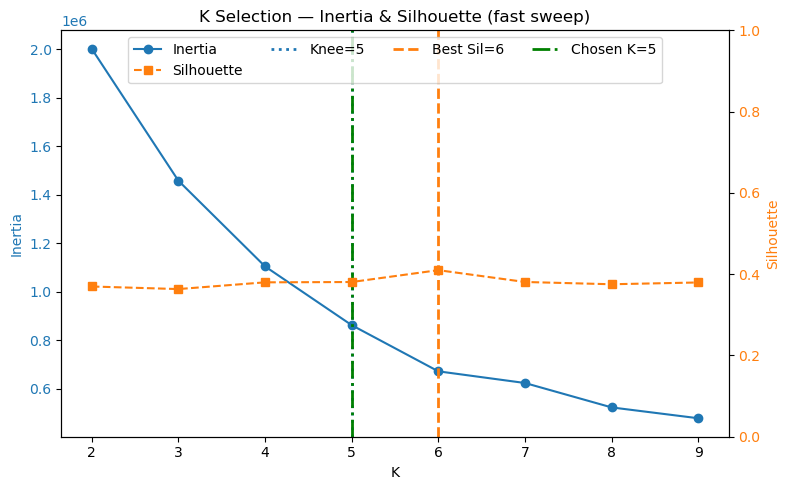

[INFO] Fitted final KMeans with K=5 and added 'cluster' to df.


In [9]:
# --- K selection (fast) for ~639k rows: MiniBatch sweep + sampled silhouette + combined plot ---

# Try to import KneeLocator; fall back gracefully
try:
    from kneed import KneeLocator
    HAVE_KNEE = True
except Exception:
    HAVE_KNEE = False

# ====== CONFIG tuned for 639k ======
K_min, K_max = 2, 9
random_state = 42

# Sweep speed knobs
n_init_sweep   = 1
max_iter_sweep = 100
batch_size     = 8192

# Silhouette sample (keeps runtime low)
sil_sample_n   = 3_000

Ks = list(range(K_min, K_max + 1))
n = Xs.shape[0]

# Sample indices for silhouette
rng = np.random.default_rng(random_state)
if sil_sample_n < n:
    sil_idx = rng.choice(n, size=sil_sample_n, replace=False)
    Xs_sil = Xs[sil_idx]
else:
    sil_idx = None
    Xs_sil = Xs

inertias = []
silhouettes = []

# ====== SWEEP ======
for k in Ks:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init=n_init_sweep,
        random_state=random_state,
        batch_size=batch_size,
        max_iter=max_iter_sweep
    )
    labels_full = mbk.fit_predict(Xs)
    inertias.append(mbk.inertia_)
    # Silhouette on sampled rows (fast)
    silhouettes.append(
        silhouette_score(Xs_sil, labels_full[sil_idx]) if sil_idx is not None
        else silhouette_score(Xs, labels_full)
    )

inertias = np.asarray(inertias, float)
silhouettes = np.asarray(silhouettes, float)

# ====== KNEE (ELBOW) ======
knee_k = None
if HAVE_KNEE:
    try:
        kneedle = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
        knee_k = int(kneedle.knee) if kneedle.knee is not None else None
    except Exception:
        knee_k = None

# ====== BEST BY SILHOUETTE ======
best_sil_k = int(Ks[np.argmax(silhouettes)])

# ====== CHOSEN K RULE ======
chosen_k = knee_k if knee_k is not None else best_sil_k

# ====== SUMMARY PRINT ======
print(f"Elbow (knee) on inertia: {knee_k if knee_k is not None else 'not detected'}")
print(f"Best silhouette: {best_sil_k} (score={silhouettes.max():.3f})")
print(f"Chosen K: {chosen_k}")

# ====== COMBINED PLOT ======
fig, ax1 = plt.subplots(figsize=(8, 5))

# Inertia (left axis)
lns1 = ax1.plot(Ks, inertias, color='#1f77b4', marker='o', label='Inertia')
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia", color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Silhouette (right axis)
ax2 = ax1.twinx()
lns2 = ax2.plot(Ks, silhouettes, color='#ff7f0e', marker='s', ls='--', label='Silhouette')
ax2.set_ylabel("Silhouette", color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim(0.0, 1.0)

handles = lns1 + lns2
labels = [h.get_label() for h in handles]

if knee_k is not None:
    v1 = ax1.axvline(knee_k, color='#1f77b4', ls=':', lw=2, label=f'Knee={knee_k}')
    handles.append(v1); labels.append(f'Knee={knee_k}')

v2 = ax1.axvline(best_sil_k, color='#ff7f0e', ls='--', lw=2, label=f'Best Sil={best_sil_k}')
handles.append(v2); labels.append(f'Best Sil={best_sil_k}')

v3 = ax1.axvline(chosen_k, color='green', ls='-.', lw=2, label=f'Chosen K={chosen_k}')
handles.append(v3); labels.append(f'Chosen K={chosen_k}')

plt.title("K Selection — Inertia & Silhouette (fast sweep)")
ax1.legend(handles, labels, loc='upper center', ncol=4, frameon=True)
plt.tight_layout()
plt.show()

# ====== Final precise fit on FULL data ======
kmeans = KMeans(n_clusters=chosen_k, n_init=10, algorithm='elkan', random_state=random_state)
df['cluster'] = kmeans.fit_predict(Xs)
print(f"[INFO] Fitted final KMeans with K={chosen_k} and added 'cluster' to df.")

In [11]:

kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(Xs)
out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[INFO] Dataset com clusters exportado: {out_csv}")

[INFO] Dataset com clusters exportado: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_results.csv


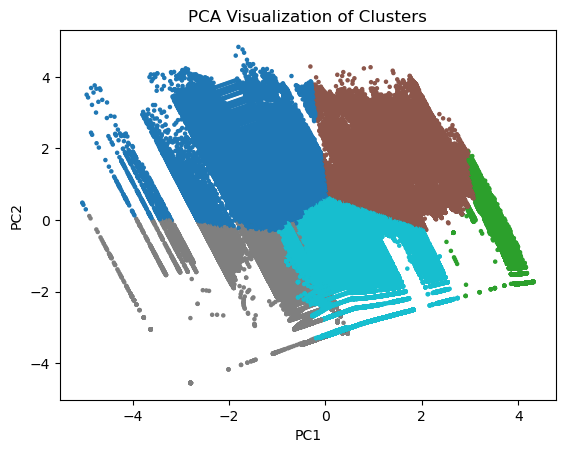

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
XY = pca.fit_transform(Xs)

plt.scatter(XY[:,0], XY[:,1], c=df["cluster"], s=5, cmap='tab10')
plt.title("PCA Visualization of Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [17]:
# -------------------------------
# Stats
# -------------------------------
sizes = df["cluster"].value_counts().sort_index()
profile_mean = df.groupby("cluster")[['usage_total','age_days','since_update_days','usage_per_365','staleness_ratio']].mean().round(2)
print("\n== Clusters Size ==\n", sizes)
print("\n== Profile (features mean) ==\n", profile_mean)

def cluster_profile(df_src, by="cluster", cols=None):
    if cols is None:
        cols = required
    g = df_src.groupby(by)[cols]
    summary = g.agg(["mean", "median", "std"]).round(2)
    q = g.quantile([0.25, 0.75]).unstack().rename(columns={0.25: "q25", 0.75: "q75"}).round(2)
    prof = pd.concat([summary, q], axis=1)
    return prof


== Clusters Size ==
 cluster
0    154438
1     27732
2    151340
3    162853
4    142743
Name: count, dtype: int64

== Profile (features mean) ==
          usage_total  age_days  since_update_days  usage_per_365  \
cluster                                                            
0            2403.88    313.01             223.07        4087.57   
1              35.89   3421.36            2677.34           3.80   
2            1117.70   1813.00            1797.77         241.23   
3              50.80    297.44             129.38          91.71   
4              37.68    775.87             766.92          24.42   

         staleness_ratio  
cluster                   
0                   0.64  
1                   0.79  
2                   0.99  
3                   0.45  
4                   0.97  
